In [61]:
library(tidyverse)

In [62]:
differential <- readRDS('C2C3_diffPeaks_for_bar.Rds')

In [63]:
differential  %>% filter(Group=='All')  %>% pull(Proportion)  %>% sum()

[1] 1

In [64]:
differential  %>% mutate(Group = case_when(Group=='All' ~ 'All',
                                           Group=='C2' ~ 'Diff_C2',
                                           Group=='C3' ~ 'Diff_C3')) -> differential2

In [65]:
Epigenetic_Genes <- readRDS('EpigeneticRegGenes_for_bar2.Rds')

In [66]:
Epigenetic_Genes  %>% mutate(Group = case_when(Group=='All' ~ 'All',
                                           Group=='C2' ~ 'EpiGene_C2',
                                           Group=='C3' ~ 'EpiGene_C3'))  %>% 
                    filter(Group %in% c('EpiGene_C2','EpiGene_C3')) -> Epigenetic_Genes2

In [67]:
Kegg_Genes <- readRDS('kegggenes_for_bar.Rds')

In [68]:
Kegg_Genes  %>% mutate(Group = case_when(Group=='All' ~ 'All',
                                           Group=='C2' ~ 'KEGG_C2',
                                           Group=='C3' ~ 'KEGG_C3'))  %>% 
                    filter(Group %in% c('KEGG_C2','KEGG_C3')) -> Kegg_Genes2

In [69]:
rbind(differential2,Epigenetic_Genes2,Kegg_Genes2) -> combined

In [70]:
combined  %>% filter(str_detect(Group,'C2')|str_detect(Group,'All')) -> combined_C2

In [71]:
combined  %>% filter(str_detect(Group,'C3')|str_detect(Group,'All')) -> combined_C3

In [72]:
combined_C2$states  <- factor(combined_C2$states, 
                                 levels = c('ActiveTSS','TssFlank','TssFlankD','TxFlank','EnhA1','EnhA2',
                                            'EnhPoised1','EnhPoised2','EnhPrimed','EnhBivalent','ReprPC'))

In [75]:
combined_C3$states  <- factor(combined_C3$states, 
                                 levels = c('ActiveTSS','TssFlank','TssFlankD','TxFlank','EnhA1','EnhA2',
                                            'EnhPoised1','EnhPoised2','EnhPrimed','EnhBivalent','ReprPC'))

In [73]:
options(repr.plot.height=6,repr.plot.width=4)
p_bar_C2 <- ggplot(data = combined_C2,aes(x=Group,y=Proportion,fill=states))+
    geom_bar(stat="identity") +theme_bw() +xlab("") +theme(axis.text = element_text(color="black",size=10))+
    scale_fill_manual(values =c("#a50026","#d73027","#f46d43","#fdae61","#fee08b","#ffffbf","#d9ef8b",
                                "#a6d96a","#66bd63","#1a9850","#1886a0","#dbdddc","#bbbcbb","#bbbcbb","#8e8e8e",
                               "#727272"))+
    theme(axis.text.x = element_text(angle=45,hjust=1))

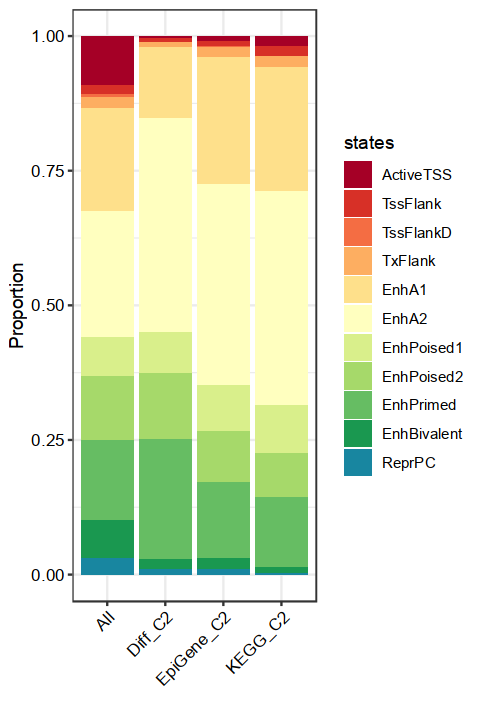

In [74]:
p_bar_C2

In [79]:
ggsave(filename = "C2_chromHMM_bar.pdf",plot = p_bar_C2,width = 4,height = 6)

In [76]:
options(repr.plot.height=6,repr.plot.width=4)
p_bar_C3 <- ggplot(data = combined_C3,aes(x=Group,y=Proportion,fill=states))+
    geom_bar(stat="identity") +theme_bw() +xlab("") +theme(axis.text = element_text(color="black",size=10))+
    scale_fill_manual(values =c("#a50026","#d73027","#f46d43","#fdae61","#fee08b","#ffffbf","#d9ef8b",
                                "#a6d96a","#66bd63","#1a9850","#1886a0","#dbdddc","#bbbcbb","#bbbcbb","#8e8e8e",
                               "#727272"))+
    theme(axis.text.x = element_text(angle=45,hjust=1))

In [80]:
ggsave(filename = "C3_chromHMM_bar.pdf",plot = p_bar_C3,width = 4,height = 6)

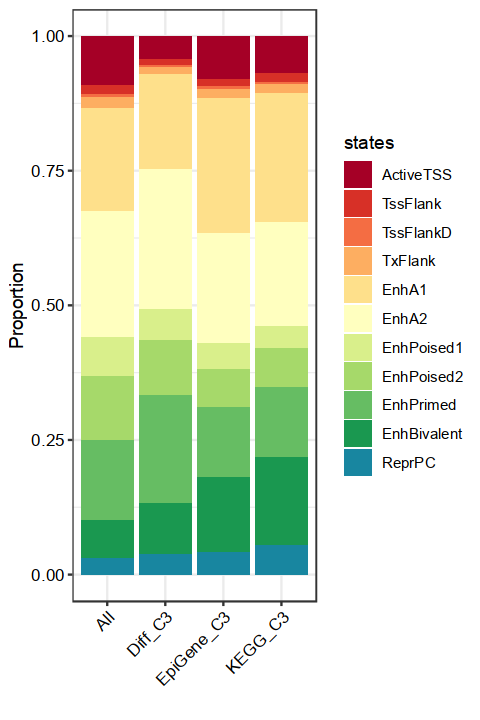

In [77]:
p_bar_C3